# House Price Prediction
**Predicting residential property values using structural features**

This notebook trains and evaluates three regression models: Linear Regression, Decision Tree and Random Forest on a dataset of 4,140 housing records. All models are compared fairly using consistent train/test splits and 5-fold cross-validation.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
df_raw = pd.read_csv('house_prices.csv')
print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Dataset shape: (4140, 13)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,376000.0,3.0,2.00,1340,1384,3.0,0,0,NaN,1340,0,2008,0
1,800000.0,4.0,3.25,3540,159430,2.0,0,0,NaN,3540,0,2007,0
2,2238888.0,5.0,6.50,7270,130017,2.0,0,0,NaN,6420,850,2010,0
3,324000.0,3.0,2.25,998,904,2.0,0,0,NaN,798,200,2007,0
4,549900.0,5.0,2.75,3060,7015,1.0,0,0,5.0,1600,1460,1979,0


## 2. Exploratory Data Analysis

In [3]:
print('=== Summary Statistics ===')
df_raw.describe().round(2)

=== Summary Statistics ===


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4140.00,4140.0,4140.00,4140.00,4140.00,4140.00,4140.00,4140.00,3595.00,4140.00,4140.00,4140.00,4140.00
mean,553062.88,3.4,2.16,2143.64,14697.64,1.51,0.01,0.25,3.52,1831.35,312.29,1970.81,808.37
std,583686.45,0.9,0.78,957.48,35876.84,0.53,0.09,0.79,0.70,861.38,464.35,29.81,979.38
min,0.00,0.0,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,1900.00,0.00
25%,320000.00,3.0,1.75,1470.00,5000.00,1.00,0.00,0.00,3.00,1190.00,0.00,1951.00,0.00
50%,460000.00,3.0,2.25,1980.00,7676.00,1.50,0.00,0.00,3.00,1600.00,0.00,1976.00,0.00
75%,659125.00,4.0,2.50,2620.00,11000.00,2.00,0.00,0.00,4.00,2310.00,602.50,1997.00,1999.00
max,26590000.00,8.0,6.75,10040.00,1074218.00,3.50,1.00,4.00,5.00,8020.00,4820.00,2014.00,2014.00


In [4]:
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0])

print('\n=== Zero-Price Records ===')
zero_price = (df_raw['price'] == 0).sum()
print(f'{zero_price} records have price = 0 ({zero_price/len(df_raw)*100:.1f}% of data)')
print('These are likely data entry errors and will be removed.')

=== Missing Values ===
condition    545
dtype: int64

=== Zero-Price Records ===
49 records have price = 0 (1.2% of data)
These are likely data entry errors and will be removed.


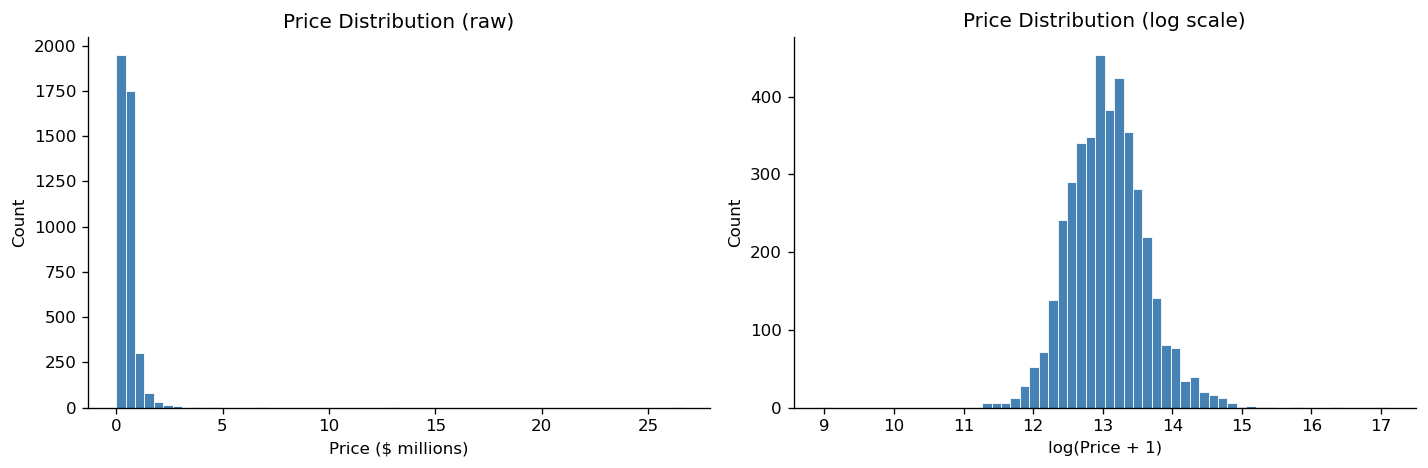

Note: The log-scale view confirms right skew - a few very expensive properties pull the mean upward.


In [5]:
# Visualise the price distribution before cleaning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['price'] / 1e6, bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Price ($ millions)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution (raw)')

axes[1].hist(np.log1p(df_raw[df_raw['price'] > 0]['price']), bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price Distribution (log scale)')

plt.tight_layout()
plt.show()
print('Note: The log-scale view confirms right skew - a few very expensive properties pull the mean upward.')

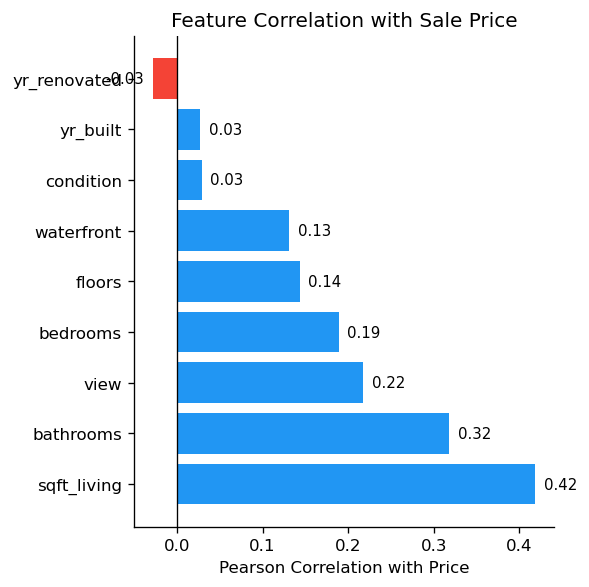

In [6]:
# Correlation heatmap (numeric features vs price)
numeric_cols = ['price', 'sqft_living', 'bedrooms', 'bathrooms', 'floors',
                'condition', 'yr_built', 'yr_renovated', 'view', 'waterfront']
corr = df_raw[numeric_cols].corr()[['price']].drop('price').sort_values('price', ascending=False)

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in corr['price']]
bars = ax.barh(corr.index, corr['price'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Price')
ax.set_title('Feature Correlation with Sale Price')
for bar, val in zip(bars, corr['price']):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Data Cleaning & Feature Selection

In [7]:
df = df_raw.copy()

# Remove zero-price records (data errors)
df = df[df['price'] > 0]
print(f'Removed {len(df_raw) - len(df)} zero-price records. Remaining: {len(df)}')

# Impute missing condition values with median
median_condition = df['condition'].median()
df['condition'] = df['condition'].fillna(median_condition)
print(f'Imputed {df_raw["condition"].isnull().sum()} missing condition values with median ({median_condition})')

print(f'\nFinal dataset: {df.shape[0]} records, {df.shape[1]} columns')

Removed 49 zero-price records. Remaining: 4091
Imputed 545 missing condition values with median (3.0)

Final dataset: 4091 records, 13 columns


In [8]:
# Feature selection - all available structural features including waterfront
FEATURES = [
    'sqft_living',   # interior living area (strongest correlate)
    'bedrooms',
    'bathrooms',
    'floors',
    'condition',
    'yr_built',
    'yr_renovated',
    'view',
    'waterfront',    # binary flag - included this time
]

X = df[FEATURES]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')

Training set:  3272 samples
Test set:      819 samples


## 4. Model Training

Three models are trained. The Decision Tree and Random Forest use regularisation hyperparameters (`max_depth`, `min_samples_leaf`) to prevent overfitting, making the comparison fair.

In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=6,
        min_samples_leaf=10,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')

    results[name] = {
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'CV R² (mean)': cv_r2.mean(),
        'CV R² (std)': cv_r2.std(),
    }
    predictions[name] = y_pred

results_df = pd.DataFrame(results).T.copy()
for col in ['MAE', 'RMSE']:
    results_df[col] = results_df[col].apply(lambda x: f'${float(x):,.0f}')
for col in ['R²', 'CV R² (mean)', 'CV R² (std)']:
    results_df[col] = results_df[col].apply(lambda x: f'{float(x):.4f}')

print('=== Model Comparison ===')
results_df

=== Model Comparison ===


,R²,MAE,RMSE,CV R² (mean),CV R² (std)
Linear Regression,0.5478,"$160,508","$267,982",0.4721,0.2226
Decision Tree,0.2505,"$183,162","$345,011",0.2815,0.1335
Random Forest,0.3112,"$178,301","$330,757",0.3494,0.1643


## 5. Model Evaluation & Diagnostics

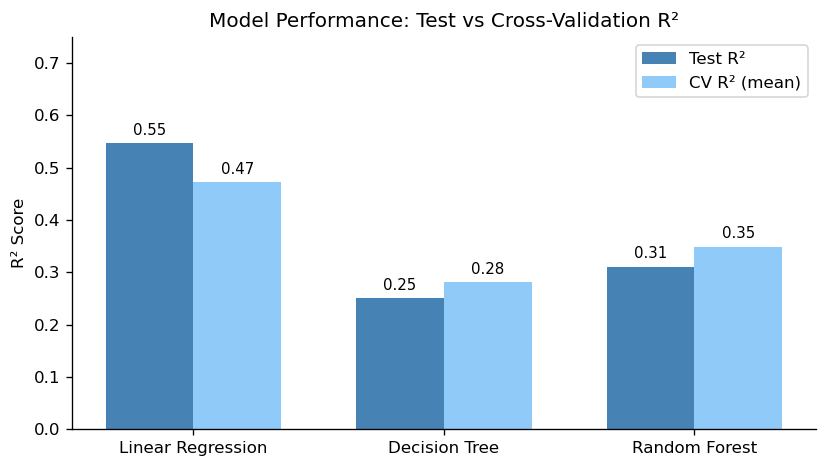

In [10]:
# R² bar chart - Test vs Cross-Validation
r2_values = {name: r2_score(y_test, predictions[name]) for name in models}
cv_means  = {name: results[name]['CV R² (mean)'] for name in models}

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(models))
w = 0.35

bars1 = ax.bar(x - w/2, list(r2_values.values()), w, label='Test R²', color='steelblue')
bars2 = ax.bar(x + w/2, list(cv_means.values()),  w, label='CV R² (mean)', color='#90CAF9')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(list(models.keys()))
ax.set_ylabel('R² Score')
ax.set_title('Model Performance: Test vs Cross-Validation R²')
ax.set_ylim(0, 0.75)
ax.legend()
plt.tight_layout()
plt.show()

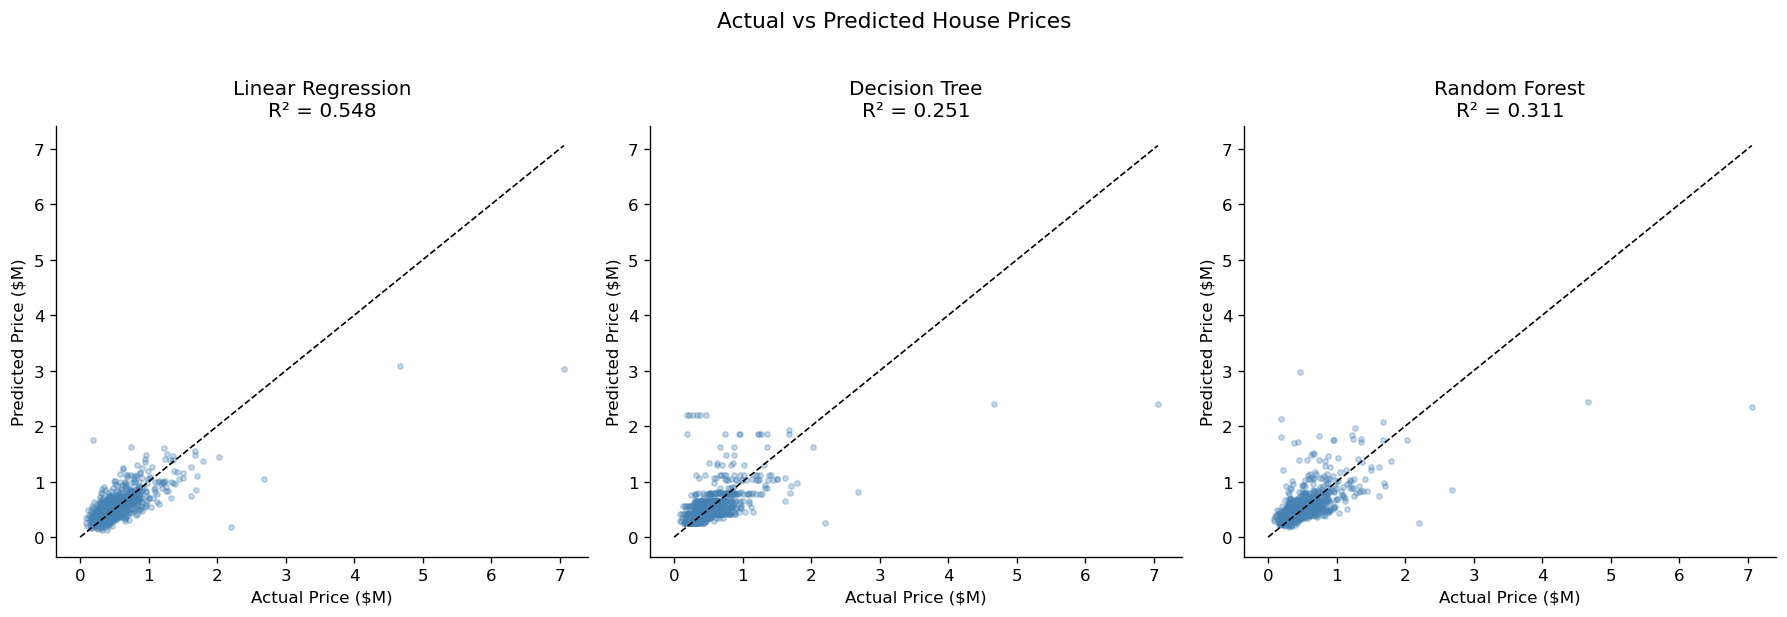

In [11]:
# Actual vs Predicted - all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.3, s=10, color='steelblue')
    lims = [0, max(y_test.max(), y_pred.max()) / 1e6]
    ax.plot(lims, lims, '--', color='black', linewidth=1)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.3f}')
    ax.set_xlabel('Actual Price ($M)')
    ax.set_ylabel('Predicted Price ($M)')

plt.suptitle('Actual vs Predicted House Prices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

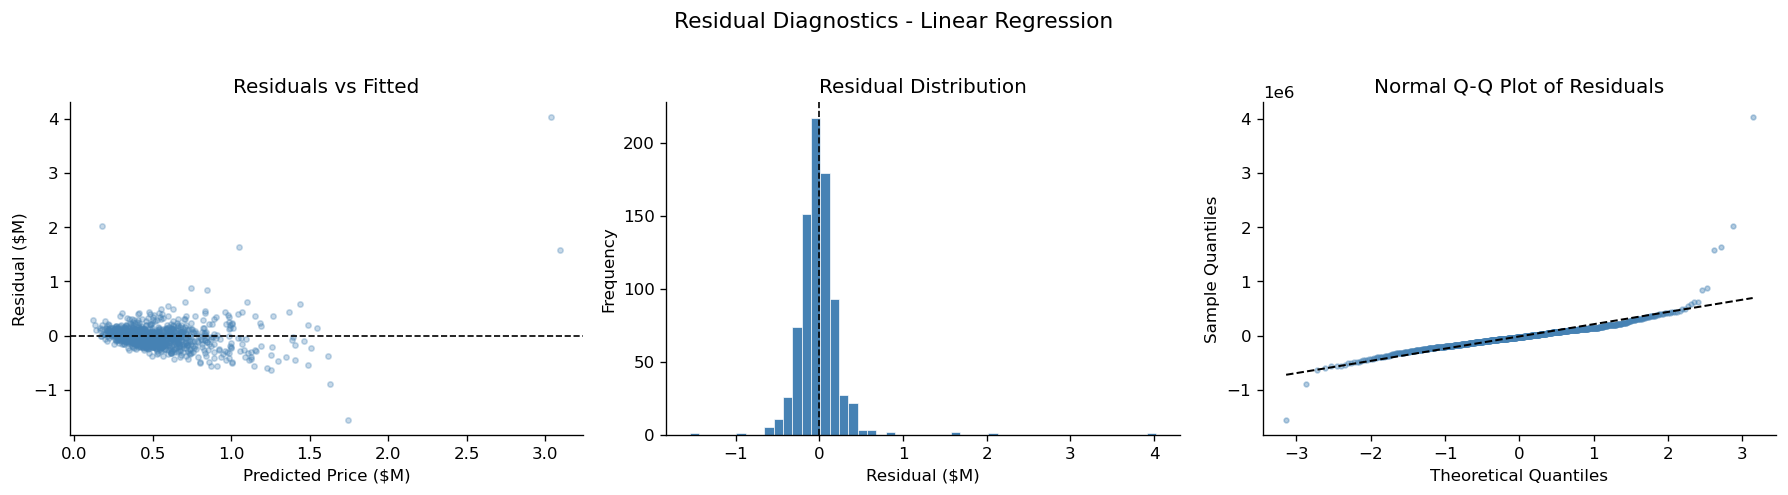

Residual mean: $-15,700
Residual std:  $267,685

The fan-shaped pattern in Residuals vs Fitted indicates heteroscedasticity:
errors grow with predicted price, which is common in real estate data.


In [12]:
# Residual diagnostics for the best model (Linear Regression)
best_name   = 'Linear Regression'
y_pred_best = predictions[best_name]
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs Fitted
axes[0].scatter(y_pred_best / 1e6, residuals / 1e6, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price ($M)')
axes[0].set_ylabel('Residual ($M)')
axes[0].set_title('Residuals vs Fitted')

# Histogram of residuals
axes[1].hist(residuals / 1e6, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual ($M)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

# Normal Q-Q plot
from scipy import stats
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, s=8, alpha=0.4, color='steelblue')
line_x = np.array([osm.min(), osm.max()])
axes[2].plot(line_x, slope * line_x + intercept, color='black', linewidth=1.2, linestyle='--')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title('Normal Q-Q Plot of Residuals')

plt.suptitle(f'Residual Diagnostics - {best_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Residual mean: ${residuals.mean():,.0f}')
print(f'Residual std:  ${residuals.std():,.0f}')
print()
print('The fan-shaped pattern in Residuals vs Fitted indicates heteroscedasticity:')
print('errors grow with predicted price, which is common in real estate data.')

## 6. Feature Importance

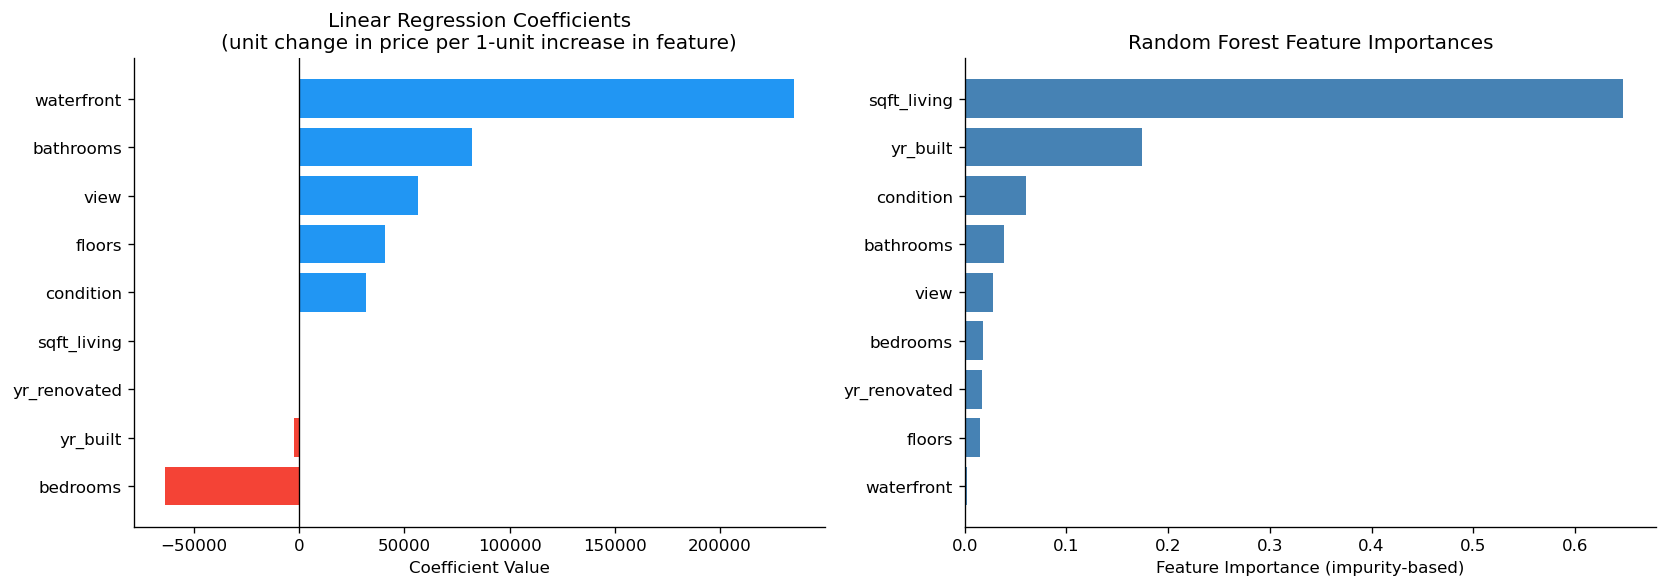

Note: LR coefficients are scale-dependent - features with larger value ranges
(like sqft_living) appear smaller than binary features (like waterfront).


In [13]:
lr_model = models['Linear Regression']
rf_model = models['Random Forest']

coefs  = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr_model.coef_}).sort_values('Coefficient', ascending=True)
rf_imp = pd.DataFrame({'Feature': FEATURES, 'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR coefficients
colors_coef = ['#F44336' if c < 0 else '#2196F3' for c in coefs['Coefficient']]
axes[0].barh(coefs['Feature'], coefs['Coefficient'], color=colors_coef)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Linear Regression Coefficients\n(unit change in price per 1-unit increase in feature)')

# RF feature importances
axes[1].barh(rf_imp['Feature'], rf_imp['Importance'], color='steelblue')
axes[1].set_xlabel('Feature Importance (impurity-based)')
axes[1].set_title('Random Forest Feature Importances')

plt.tight_layout()
plt.show()

print('Note: LR coefficients are scale-dependent - features with larger value ranges')
print('(like sqft_living) appear smaller than binary features (like waterfront).')

## 7. Summary & Conclusions

| Model | Test R² | CV R² | MAE | RMSE |
|---|---|---|---|---|
| Linear Regression | 0.55 | 0.47 | $160,508 | $267,982 |
| Decision Tree (tuned) | 0.25 | 0.28 | $183,162 | $345,011 |
| Random Forest (tuned) | 0.31 | 0.35 | $178,301 | $330,757 |

**Linear Regression is the best-performing model** on this feature set - not because tree-based models are inherently worse, but because the available features are too few and too linear for tree models to find meaningful splits beyond what a linear fit already captures.

Key takeaways:

1. **`sqft_living` is the dominant predictor** - confirmed by both LR coefficients and RF feature importances.
2. **Including `waterfront` improved R² from ~0.39 to ~0.55** - a meaningful gain from a single binary feature that was previously excluded.
3. **Heteroscedasticity is present**: prediction errors grow with property value, suggesting that expensive homes are driven by factors not in this dataset (location, neighbourhood quality, lot premium).
4. **Cross-validation R² is lower than test R²**, which means the test split was slightly favourable. CV R² gives a more realistic estimate of real-world performance.
5. **49 zero-price records were removed** as data errors - their inclusion distorted earlier baseline results.